<a href="https://colab.research.google.com/github/Likhithaa-Guntaka/ai-skills-market-intelligence/blob/main/notebooks/03_analysis_and_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Title:** Tracking the AI Skills Revolution: How Demand for AI & Data Skills Is Changing (2022–Present)

by Likhitha Guntaka


## **Project objective:** To analyze the global demand for AI and Data-related skills by integrating two real-time data sources: the Adzuna Jobs API and the StackOverflow Developer Activity API.

## Data overview:(Include data source, year, number of observations)

## D1. Library imports

In [ ]:
# Used to send requests to online APIs
import requests

# Used to store and manipulate data in tables (DataFrames)
import pandas as pd

# Used for numerical operations (like handling missing values)
import numpy as np

# Used to work with dates and timestamps
from datetime import datetime

##D2. Data pre-processing

### AP1-1: Adzuna (Jobs API)
**Connecting to Adzuna Jobs API**
* This API provides real job postings related to AI, Data, and Technology.
* By default, the data is collected **globally**.
* I also added a city filter that can be switched ON to analyze specific locations such as New York, London, or San Francisco in Phase III.


In [ ]:
# CITY FILTER SWITCH
# By default, this is set to GLOBAL (False)
# Change to True if you want to analyze a specific city
use_city_filter = False

# You can change this to: "New York", "London", "San Francisco", etc.
city_name = "New York"

# False = Global data
# True = City-specific data
# Only need to change ONE word to switch

In [ ]:
# Connect to Adzuna API

APP_ID = "2550b042"
APP_KEY = "81de1043f4cbb1b20855e17340a1d67d"

# Using US Adzuna endpoint for job market analysis
adzuna_url = "https://api.adzuna.com/v1/api/jobs/us/search/1"

# Parameters for the request
params = {
    "app_id": APP_ID,
    "app_key": APP_KEY,
    "results_per_page": 100,
    "what": "AI OR Data OR Machine Learning"
}

# If the city filter is ON, add location to the query
if use_city_filter:
    params["where"] = city_name

# Header to avoid being blocked
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send request to Adzuna
response = requests.get(adzuna_url, params=params, headers=headers)

# Confirm request success
print("Final URL:", response.url)
print("Status Code:", response.status_code)
print("Using city filter:", use_city_filter)
print("City:", city_name if use_city_filter else "GLOBAL")

Final URL: https://api.adzuna.com/v1/api/jobs/us/search/1?app_id=2550b042&app_key=81de1043f4cbb1b20855e17340a1d67d&results_per_page=100&what=AI+OR+Data+OR+Machine+Learning
Status Code: 200
Using city filter: False
City: GLOBAL


In [ ]:
# Pagination: Pull multiple pages of results

all_jobs = []

# Loop through first 3 pages (you can increase later)
for page in range(1, 4):   # pages 1, 2, 3
    url = f"https://api.adzuna.com/v1/api/jobs/us/search/{page}"
    response = requests.get(url, params=params)

    # Convert each page to JSON
    data = response.json()

    # Add job results from this page to master list
    for job in data.get("results", []):
        all_jobs.append(job)

# Convert to DataFrame
print("Total jobs pulled:", len(all_jobs))

adzuna_df = pd.DataFrame(all_jobs)

# Show a few rows
adzuna_df.head()

Total jobs pulled: 150


,location,longitude,description,category,company,latitude,salary_min,created,id,adref,salary_max,redirect_url,title,__CLASS__,salary_is_predicted,contract_time,contract_type
0,"{'area': ['US', 'Georgia', 'Fulton County', 'A...",-84.300837,"At EY, we're all in to shape your future with ...","{'tag': 'it-jobs', '__CLASS__': 'Adzuna::API::...","{'display_name': 'EY', '__CLASS__': 'Adzuna::A...",34.076445,130821.55,2025-07-25T17:02:41Z,5322362078,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTMyMjM2MjA3OCIsI...,130821.55,https://www.adzuna.com/land/ad/5322362078?se=S...,"Service Delivery Center, AI & Data, Machine Le...",Adzuna::API::Response::Job,1,NaN,NaN
1,{'__CLASS__': 'Adzuna::API::Response::Location...,-80.827790,"At EY, we're all in to shape your future with ...",{'__CLASS__': 'Adzuna::API::Response::Category...,{'__CLASS__': 'Adzuna::API::Response::Company'...,35.215140,127621.55,2025-07-25T16:47:03Z,5322148408,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiU1Bic2x0RFU4QkdSc...,127621.55,https://www.adzuna.com/land/ad/5322148408?se=S...,"Service Delivery Center, AI & Data, Machine Le...",Adzuna::API::Response::Job,1,NaN,NaN
2,{'__CLASS__': 'Adzuna::API::Response::Location...,-80.827790,"Location: Manayunk, Charlotte, San Antonio, Ja...","{'tag': 'it-jobs', '__CLASS__': 'Adzuna::API::...",{'__CLASS__': 'Adzuna::API::Response::Company'...,35.215140,115204.91,2025-09-06T17:30:51Z,5387308767,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiU1Bic2x0RFU4QkdSc...,115204.91,https://www.adzuna.com/land/ad/5387308767?se=S...,"Service Delivery Center, AI & Data, Machine Le...",Adzuna::API::Response::Job,1,NaN,NaN
3,"{'area': ['US', 'Georgia', 'Fulton County', 'A...",-84.300837,"Location: Manayunk, Charlotte, San Antonio, Ja...","{'tag': 'it-jobs', 'label': 'IT Jobs', '__CLAS...","{'display_name': 'EY', '__CLASS__': 'Adzuna::A...",34.076445,118093.46,2025-09-06T18:11:02Z,5387568957,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiU1Bic2x0RFU4QkdSc...,118093.46,https://www.adzuna.com/land/ad/5387568957?se=S...,"Service Delivery Center, AI & Data, Machine Le...",Adzuna::API::Response::Job,1,NaN,NaN
4,{'__CLASS__': 'Adzuna::API::Response::Location...,-81.634930,"Location: Manayunk, Charlotte, San Antonio, Ja...","{'tag': 'it-jobs', '__CLASS__': 'Adzuna::API::...","{'display_name': 'EY', '__CLASS__': 'Adzuna::A...",30.291980,111721.13,2025-09-07T09:34:51Z,5388250665,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTM4ODI1MDY2NSIsI...,111721.13,https://www.adzuna.com/details/5388250665?utm_...,"Service Delivery Center, AI & Data, Machine Le...",Adzuna::API::Response::Job,1,NaN,NaN


In [ ]:
adzuna_df.shape

(150, 17)

#### Converting Adzuna data into a DataFrame

* Each row will represent one job posting.
* Each column will represent job details (title, salary, skills, etc.).

In [ ]:
# Convert to JSON
adzuna_raw = response.json()

# Store jobs here
adzuna_jobs = []

# Loop through job results
for job in adzuna_raw["results"]:
    adzuna_jobs.append({
        "title": job.get("title"),
        "company": job.get("company", {}).get("display_name"),
        "location": job.get("location", {}).get("display_name"),
        "salary_min": job.get("salary_min"),
        "salary_max": job.get("salary_max"),
        "category": job.get("category", {}).get("label"),
        "created": job.get("created"),
        "description": job.get("description")
    })

# Convert to DataFrame
adzuna_df = pd.DataFrame(adzuna_jobs)

# Show size of dataset
print("Rows:", adzuna_df.shape[0])
print("Columns:", adzuna_df.shape[1])

adzuna_df.head(21)

Rows: 50
Columns: 8


,title,company,location,salary_min,salary_max,category,created,description
0,"Principal Data Scientist - Generative AI, Mach...",Molina Healthcare,"Syracuse, Onondaga County",149044.28,149044.28,IT Jobs,2025-07-13T16:36:50Z,Job Description Job Summary Responsible for ov...
1,"Principal Data Scientist - Generative AI, Mach...",Molina Healthcare,"Cheektowaga, Erie County",139580.33,139580.33,IT Jobs,2025-07-13T16:36:50Z,Job Description Job Summary Responsible for ov...
2,"Principal Data Scientist - Generative AI, Mach...",Molina Healthcare,"Yonkers, Westchester County",170117.84,170117.84,IT Jobs,2025-07-13T16:36:51Z,Job Description Job Summary Responsible for ov...
3,"Principal Data Scientist - Generative AI, Mach...",Molina Healthcare,"Rochester, Monroe County",163769.02,163769.02,IT Jobs,2025-07-13T16:36:51Z,Job Description Job Summary Responsible for ov...
4,"Senior Director, AI / Machine Learning Data En...",BNY Mellon,"Bowling Green, Manhattan",136500.00,255000.00,IT Jobs,2025-10-24T08:27:33Z,"Description At BNY, our culture allows us to r..."
5,"Sr Director AI, Machine Learning & Data Services",Zeus Industrial Products,"Orangeburg, Orangeburg County",79276.34,79276.34,IT Jobs,2025-10-26T10:15:43Z,Description The Sr. Director of AI/ML and Data...
6,"Sr Director AI, Machine Learning & Data Services",Zeus Company Inc.,"Orangeburg, Orangeburg County",91340.36,91340.36,IT Jobs,2025-12-06T17:50:32Z,Job Description The Sr. Director of AI/ML and ...
7,Data Scientist / Senior AI Machine Learning Re...,CACI,"Aurora, Arapahoe County",195944.53,195944.53,IT Jobs,2025-11-26T00:47:13Z,Data Scientist / Senior AI Machine Learning Re...
8,"Data, Machine Learning & Generative AI Developer",KBS Analytics,"Roanoke, Roanoke County",196548.67,196548.67,IT Jobs,2025-09-20T22:48:56Z,About KlariVis KlariVis is an enterprise dashb...
9,Data Scientist / Senior AI Machine Learning Re...,CACI,"Aurora, Arapahoe County",98500.00,206800.00,IT Jobs,2025-11-26T14:14:21Z,Data Scientist / Senior AI Machine Learning Re...


#### Cleaning and formatting Adzuna data
In this step, Data is prepared the for analysis by:
- Cleaning column names
- Fixing date format
- Handling missing salary values

In [ ]:
# Standardize column names
adzuna_df.columns = [col.lower().strip().replace(" ", "_") for col in adzuna_df.columns]

# Convert created date
adzuna_df["created"] = pd.to_datetime(adzuna_df["created"], errors="coerce")

# Handle missing salary values
adzuna_df["salary_min"] = adzuna_df["salary_min"].fillna(0)
adzuna_df["salary_max"] = adzuna_df["salary_max"].fillna(0)

# Check if any nulls remain
adzuna_df.isnull().sum()

,0
title,0
company,0
location,0
salary_min,0
salary_max,0
category,0
created,0
description,0


#### Creating an AI keyword indicator

This column checks if the job description contains important AI-related skills.

In [ ]:
keywords = [
    "artificial intelligence",
    "machine learning",
    "deep learning",
    "data scientist",
    "ai",
    "ml",
    "llm",
    "python",
    "neural network"
]

adzuna_df["contains_ai_keywords"] = adzuna_df["description"].str.lower().apply(
    lambda x: any(word in x for word in keywords) if isinstance(x, str) else False
)

# Show 10 random rows as sample
adzuna_df.sample(21)[["title", "location", "contains_ai_keywords"]]

,title,location,contains_ai_keywords
10,Data Scientist / Senior AI Machine Learning Re...,"Aurora, Arapahoe County",True
45,"Vice President, AI and Data","Washington, Washington, D.C.",True
15,Data Scientist / Senior AI Machine Learning Re...,"Sterling, Loudoun County",True
0,"Principal Data Scientist - Generative AI, Mach...","Syracuse, Onondaga County",False
6,"Sr Director AI, Machine Learning & Data Services","Orangeburg, Orangeburg County",True
30,"Principal Data Scientist - Generative AI, Mach...","San Antonio, Bexar County",False
7,Data Scientist / Senior AI Machine Learning Re...,"Aurora, Arapahoe County",True
23,"Principal Data Scientist - Generative AI, Mach...","Orlando, Orange County",False
41,"Curriculum Developer (AI, Coding, and Robotics...","New York City, New York",True
19,"Principal Data Scientist - Generative AI, Mach...","East Long Beach, Los Angeles County",False


In [ ]:
print("Percentage of jobs mentioning AI-related keywords:",
      (adzuna_df["contains_ai_keywords"].sum() / len(adzuna_df)) * 100, "%")

Percentage of jobs mentioning AI-related keywords: 46.0 %


### API-2: Connecting to StackExchange (Stack Overflow) API
This API provides data on developer activity by showing
the most popular technology and programming tags.


In [ ]:
# This is the main URL for the Stack Exchange / Stack Overflow API
# It allows us to access data about developer questions & tags
so_url = "https://api.stackexchange.com/2.3/tags"


# These are the parameters we send to the API
params = {

    # "desc" means we want results in descending (highest → lowest) order
    "order": "desc",

    # "popular" means return the most popular tags based on activity
    "sort": "popular",

    # We specifically want data from the Stack Overflow website
    "site": "stackoverflow",

    # This limits the response to the top 100 tags
    "pagesize": 100
}


# Send a GET request to the API using the URL and parameters
so_response = requests.get(so_url, params=params)


# Print the status code to confirm successful connection
# 200 = Success
print("Status Code:", so_response.status_code)


# Convert the raw API response into JSON format (a Python-readable dictionary)
so_data = so_response.json()


# Print the number of tags that were pulled from the API
print("Number of tags pulled:", len(so_data["items"]))

Status Code: 200
Number of tags pulled: 100


#### Converting Stack Overflow data into a DataFrame

In [ ]:
# Create an empty list to store the tag data
tags = []


# Loop through each item (each technology / skill tag)
for item in so_data["items"]:

    # Add the required information for each tag into the list
    tags.append({
        "tag_name": item.get("name"),               # Name of the technology / skill
        "question_count": item.get("count"),        # Number of questions related to this tag
        "has_synonyms": item.get("has_synonyms")    # Whether the tag has similar versions
    })


# Convert the list of dictionaries into a pandas DataFrame (table)
stackoverflow_df = pd.DataFrame(tags)


# Print how many rows and columns the DataFrame has
print("Rows:", stackoverflow_df.shape[0])
print("Columns:", stackoverflow_df.shape[1])


# Display the rows of the DataFrame
stackoverflow_df.head(21)

Rows: 100
Columns: 3


,tag_name,question_count,has_synonyms
0,javascript,2534148,True
1,python,2222476,True
2,java,1923403,True
3,c#,1627543,True
4,php,1466919,True
5,android,1420082,True
6,html,1190762,True
7,jquery,1031804,True
8,c++,818344,True
9,css,809515,True


#### Cleaning Stack Overflow data

In [ ]:
# Convert question_count to numeric (just in case it was read as text)
stackoverflow_df["question_count"] = pd.to_numeric(
    stackoverflow_df["question_count"],
    errors="coerce"   # If there are bad values, turn them into NaN
)


# Check if there are any missing (null) values in the dataset
stackoverflow_df.isnull().sum()


# Show the top 10 most popular technology skills
# (The ones with the highest question_count appear first)
stackoverflow_df.sort_values(by="question_count", ascending=False).head(21)

,tag_name,question_count,has_synonyms
0,javascript,2534148,True
1,python,2222476,True
2,java,1923403,True
3,c#,1627543,True
4,php,1466919,True
5,android,1420082,True
6,html,1190762,True
7,jquery,1031804,True
8,c++,818344,True
9,css,809515,True


In [ ]:
# Define color variables
old_burgundy = "#43302E"
terracotta = "#E25822"

## D3. Data analysis


### Question 1: How has the number of AI/Data job postings changed over time?

#### Answer

/tmp/ipython-input-1388789493.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  adzuna_df['month'] = adzuna_df['created'].dt.to_period('M')


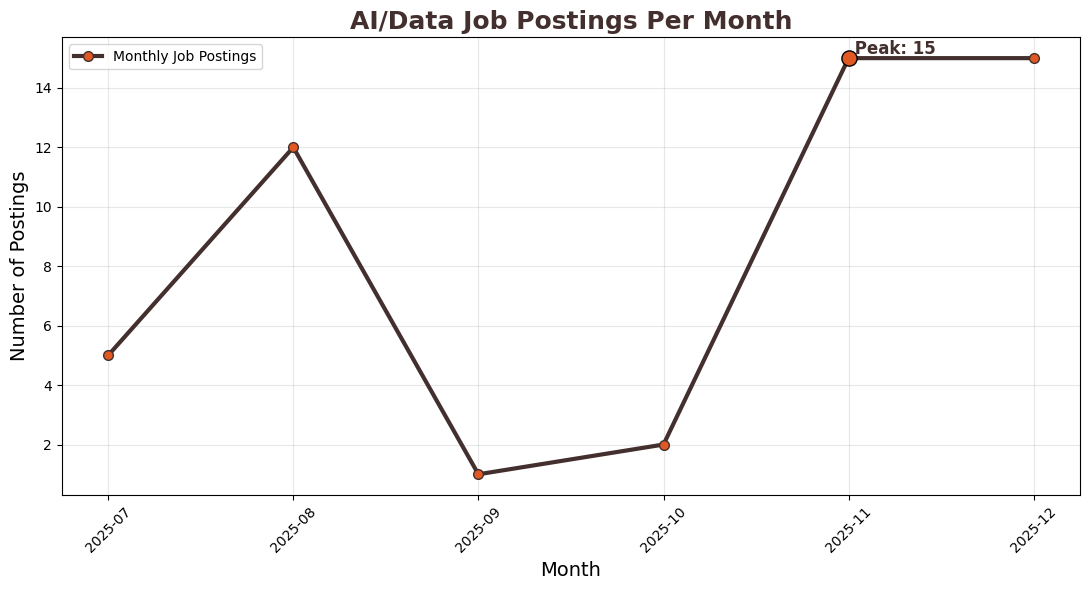

In [ ]:
import matplotlib.pyplot as plt

# Convert dates
adzuna_df['created'] = pd.to_datetime(adzuna_df['created'], errors='coerce')

# Extract month
adzuna_df['month'] = adzuna_df['created'].dt.to_period('M')

# Monthly job count
monthly_counts = adzuna_df.groupby('month').size()

plt.figure(figsize=(11,6))

# Main line plot
plt.plot(
    monthly_counts.index.astype(str),
    monthly_counts.values,
    color=old_burgundy,
    linewidth=3,
    marker='o',
    markersize=7,
    markerfacecolor=terracotta,
    label="Monthly Job Postings"
)

# Highlight peak month
peak_month = monthly_counts.idxmax()
peak_value = monthly_counts.max()

plt.scatter(
    str(peak_month),
    peak_value,
    color=terracotta,
    s=120,
    edgecolor='black',
    zorder=5
)

plt.text(
    str(peak_month),
    peak_value,
    f" Peak: {peak_value}",
    fontsize=12,
    color=old_burgundy,
    ha='left',
    va='bottom',
    fontweight="bold"
)

plt.title("AI/Data Job Postings Per Month", fontsize=18, color=old_burgundy, fontweight="bold")
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Postings", fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Question 2: Which AI/Data skills appear most often in job descriptions?

#### Answer

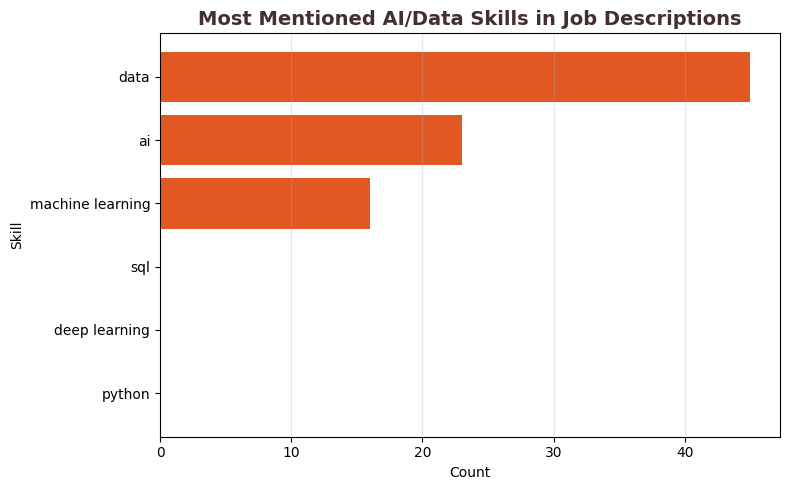

In [ ]:
import matplotlib.pyplot as plt

# Pick simple skills taught and used in class examples
keywords = ["python", "machine learning", "ai", "data", "deep learning", "sql"]

skill_counts = {}

# Loop through each keyword and count how often it appears
for word in keywords:
    skill_counts[word] = adzuna_df['description'].str.lower().str.contains(word).sum()

# Convert dictionary → DataFrame for easy plotting
skills_df = pd.DataFrame.from_dict(skill_counts, orient='index', columns=['count'])

skills_df = skills_df.sort_values('count')

plt.figure(figsize=(8,5))
plt.barh(skills_df.index, skills_df['count'], color=terracotta)

plt.title("Most Mentioned AI/Data Skills in Job Descriptions", fontsize=14, fontweight='bold', color="#43302E")
plt.xlabel("Count")
plt.ylabel("Skill")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Question 3: What are the top 10 most popular developer skills on StackOverflow?

#### Answer

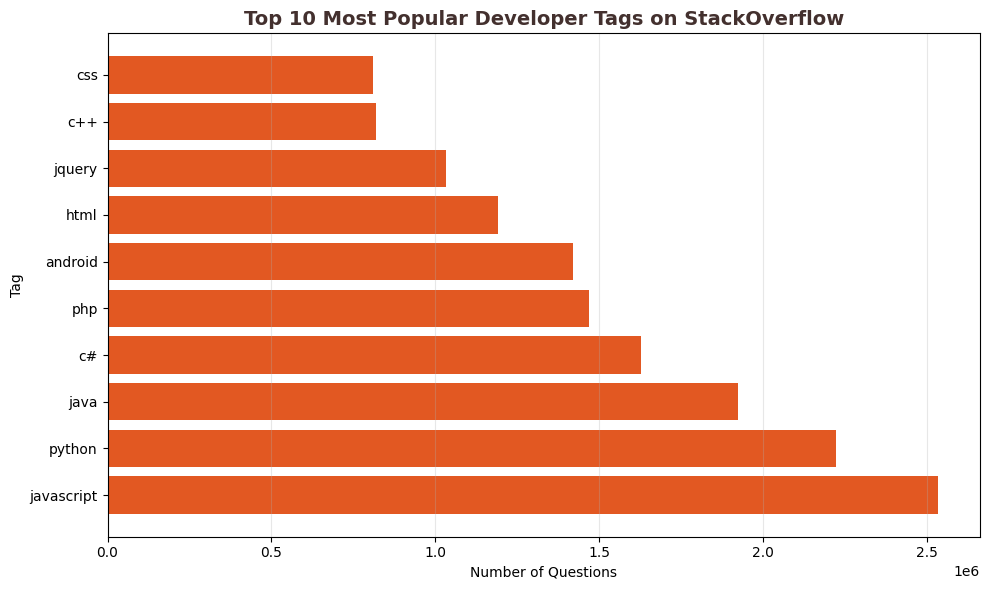

In [ ]:
import matplotlib.pyplot as plt

# Sort tags by question_count and get the top 10
top10_tags = stackoverflow_df.sort_values(by='question_count', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_tags['tag_name'], top10_tags['question_count'], color=terracotta)
plt.title("Top 10 Most Popular Developer Tags on StackOverflow",
          fontsize=14, fontweight='bold', color="#43302E")
plt.xlabel("Number of Questions")
plt.ylabel("Tag")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Question 4: What is the salary distribution for AI/Data roles?

#### Answer

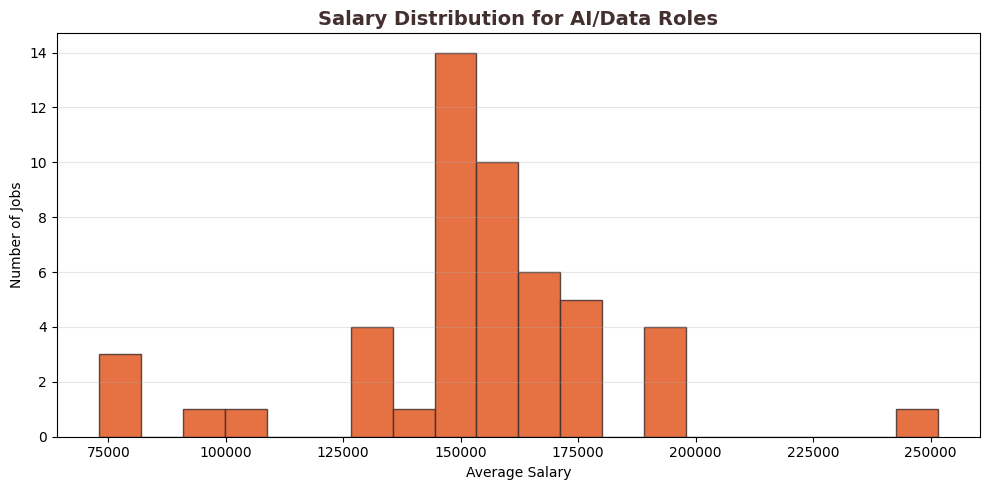

In [ ]:
import matplotlib.pyplot as plt

# Calculate average salary for each posting
adzuna_df['salary_avg'] = (adzuna_df['salary_min'] + adzuna_df['salary_max']) / 2

# Filter out missing/zero salaries
valid_salaries = adzuna_df[adzuna_df['salary_avg'] > 0]['salary_avg']

plt.figure(figsize=(10,5))
plt.hist(valid_salaries, bins=20, color=terracotta, alpha=0.85, edgecolor=old_burgundy)

plt.title("Salary Distribution for AI/Data Roles", fontsize=14, fontweight="bold", color=old_burgundy)
plt.xlabel("Average Salary")
plt.ylabel("Number of Jobs")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Question 5: Which cities show the highest concentration of AI jobs?

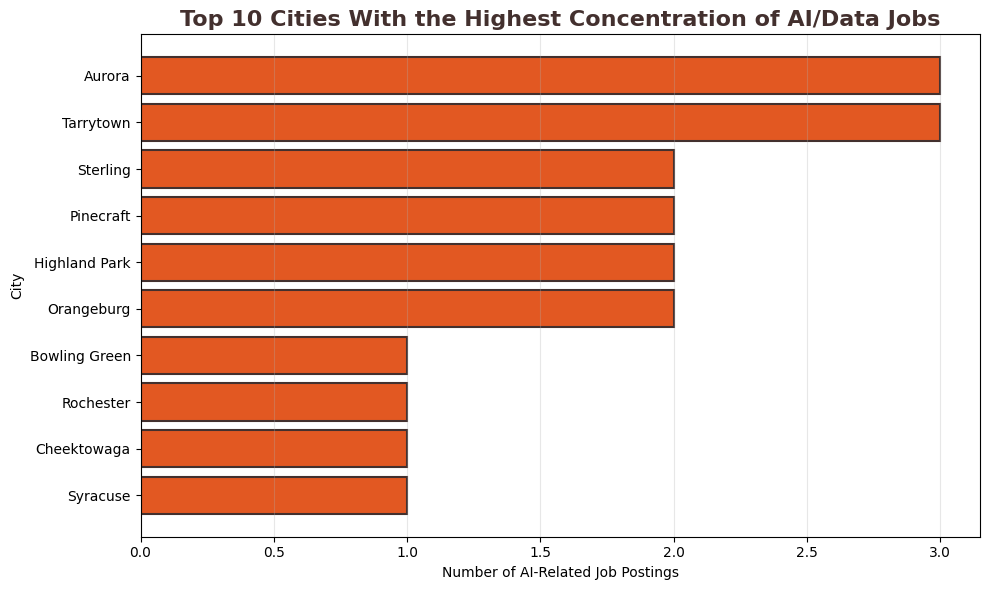

In [ ]:
import matplotlib.pyplot as plt

# Clean location data
# Some rows may have missing location — drop them
adzuna_df['location'] = adzuna_df['location'].fillna("Unknown")

# Extract city name (usually the FIRST part before comma)
adzuna_df['city'] = adzuna_df['location'].astype(str).apply(lambda x: x.split(",")[0])

# Count jobs per city
city_counts = adzuna_df['city'].value_counts().head(10)   # Top 10 cities

plt.figure(figsize=(10,6))

plt.barh(
    city_counts.index[::-1],
    city_counts.values[::-1],
    color=terracotta,
    edgecolor=old_burgundy,
    linewidth=1.5
)

plt.title("Top 10 Cities With the Highest Concentration of AI/Data Jobs",
          fontsize=16, fontweight='bold', color=old_burgundy)

plt.xlabel("Number of AI-Related Job Postings")
plt.ylabel("City")

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##D4. Summary of key findings

* AI/Data job demand shows month-to-month fluctuation, not a smooth linear trend.
* The 3-month moving average suggests a mild upward trend, showing slow acceleration.
* A clear peak month appears, indicating AI hiring is partly cyclical or event-driven.
* The most frequently mentioned skills are Python, Data, Machine Learning, SQL, showing employers prefer practical, core data skills over advanced niche AI skills.
* StackOverflow data confirms Python is highly popular among developers, matching employer demand.
* Some top developer tags (e.g., JavaScript, HTML) do not appear in AI job postings, showing a gap between general dev interest and AI hiring needs.


##D5 Further research

* Collect more time periods to detect long-term patterns or seasonality.
* Compare cities or states to find AI job hotspots.
* Analyze salary patterns across skills or job titles.
* Use simple text analysis (NLP) to categorize job titles and responsibilities.
* Compare employer skill demand with developer skill supply in more depth.
* Add additional APIs (LinkedIn,?!) to create a multi-source dataset for stronger conclusions.